# PlacementDETR Demo

Predict plausible bounding box placements for object classes on background images.

**Model:** PlacementDETR — a class-conditioned DETR that predicts where an object could plausibly be placed in a scene.

**Checkpoint:** Auto-downloaded from [HuggingFace](https://huggingface.co/datasets/marco-schouten/hidden-objects), or provide your own.

In [ ]:
# Install dependencies (uncomment if needed)
# !pip install torch torchvision numpy Pillow matplotlib huggingface_hub

In [1]:
import random
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from model import PlacementDETR, MultiScaleBackbone, center_crop, IMG_SIZE, IMG_MEAN, IMG_STD

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load model

Downloads the checkpoint from HuggingFace if not already present in `checkpoints/`.

In [2]:
CKPT_DIR = Path("checkpoints")
CKPT_PATH = CKPT_DIR / "placement_detr_ho.pth"

if not CKPT_PATH.exists():
    from huggingface_hub import hf_hub_download
    print("Downloading checkpoint from HuggingFace...")
    hf_hub_download(
        repo_id="marco-schouten/hidden-objects",
        filename="checkpoints/placement_detr_ho.pth",
        repo_type="dataset",
        local_dir=".",
    )

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
classes = ckpt["classes"]
class_to_idx = {c: i for i, c in enumerate(classes)}

model = PlacementDETR(
    num_classes=len(classes),
    num_queries=ckpt["model"]["query_offsets"].shape[0],
    use_cached_features=True,
)
model.load_state_dict(ckpt["model"])
model.to(device).eval()

backbone = MultiScaleBackbone().to(device).eval()

print(f"Loaded model with {len(classes)} classes:")
print(classes)

Loaded model with 28 classes:
['airplane', 'apple', 'bench', 'bicycle', 'boat', 'book', 'bottle', 'cake', 'car', 'cat', 'cell phone', 'chair', 'cow', 'cup', 'dog', 'elephant', 'fire hydrant', 'horse', 'keyboard', 'laptop', 'motorcycle', 'person', 'pizza', 'potted plant', 'sandwich', 'suitcase', 'vase', 'wine glass']


## Inference & visualization helpers

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

def predict(image_path, class_name, top_k=5):
    """Predict top-k plausible placements for class_name on the background image."""
    image = Image.open(image_path).convert("RGB")
    img = center_crop(image, IMG_SIZE)
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feats = backbone(img_tensor)
        cls_tensor = torch.tensor([class_to_idx[class_name]], device=device)
        pred_boxes, pred_plaus = model(feats, cls_tensor)

    scores = torch.sigmoid(pred_plaus[0]).cpu().numpy()
    boxes = pred_boxes[0].cpu().numpy()
    sorted_idx = np.argsort(-scores)[:top_k]

    preds = []
    for idx in sorted_idx:
        x, y, w, h = boxes[idx]
        x1, y1 = max(0.0, x), max(0.0, y)
        x2, y2 = min(1.0, x + w), min(1.0, y + h)
        preds.append({
            "bbox": [round(float(v), 4) for v in [x1, y1, x2 - x1, y2 - y1]],
            "score": round(float(scores[idx]), 4),
        })
    return img, preds


def show(img, preds, class_name):
    """Display image with predicted bounding boxes."""
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(img)
    colors = plt.cm.Set1(np.linspace(0, 1, max(len(preds), 1)))
    for i, p in enumerate(preds):
        x, y, w, h = p["bbox"]
        rect = patches.Rectangle(
            (x * IMG_SIZE, y * IMG_SIZE), w * IMG_SIZE, h * IMG_SIZE,
            linewidth=2, edgecolor=colors[i], facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(x * IMG_SIZE, y * IMG_SIZE - 4, f"#{i+1} ({p['score']:.2f})",
                color=colors[i], fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    ax.set_title(f'PlacementDETR — "{class_name}"')
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Run on demo images

Each example pairs a background scene with an object class. The model predicts the top-5 most plausible bounding box placements.

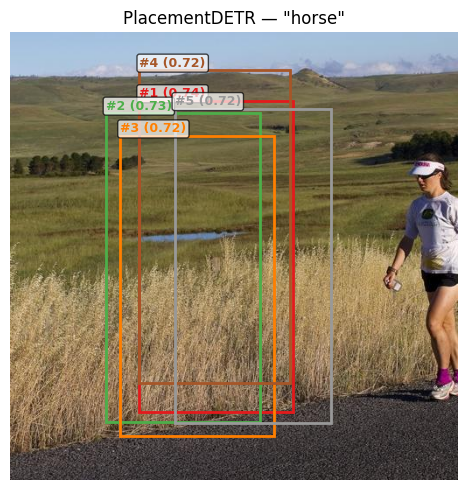

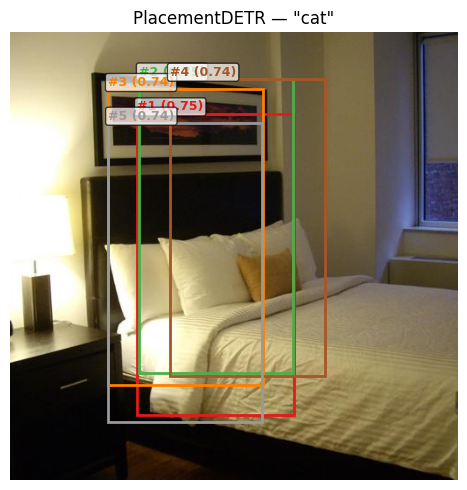

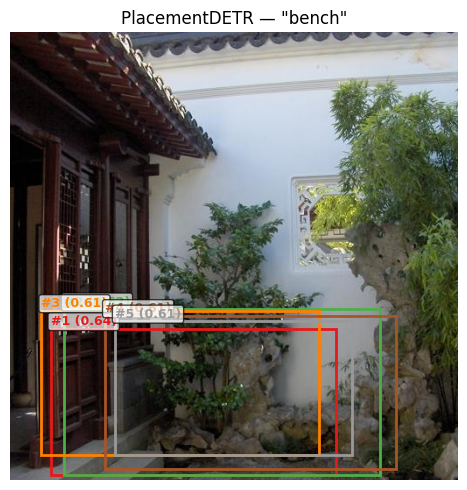

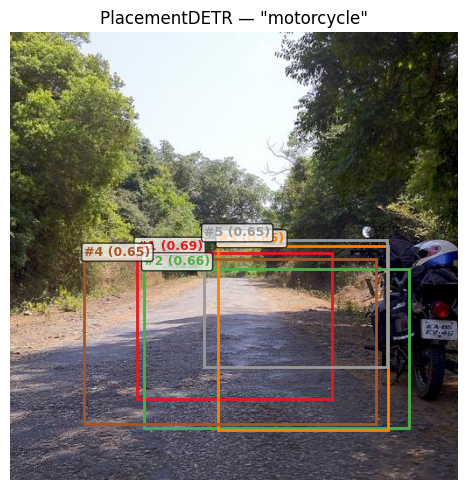

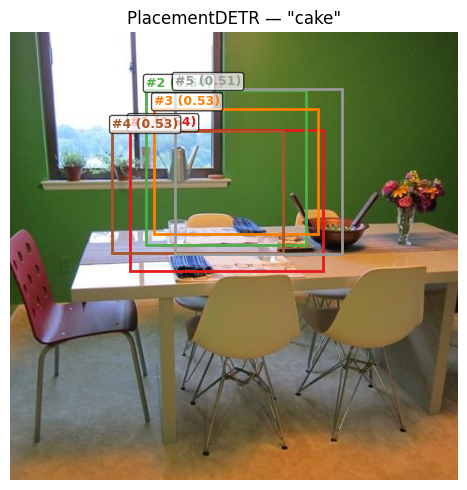

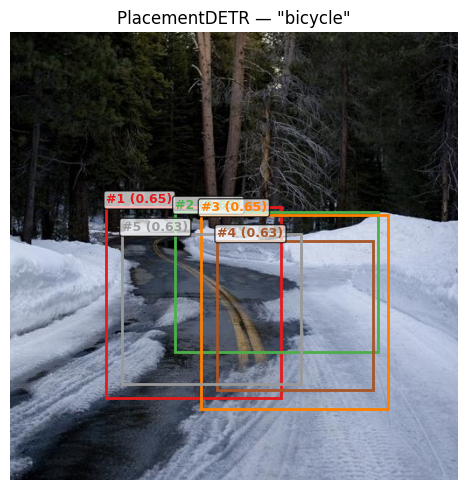

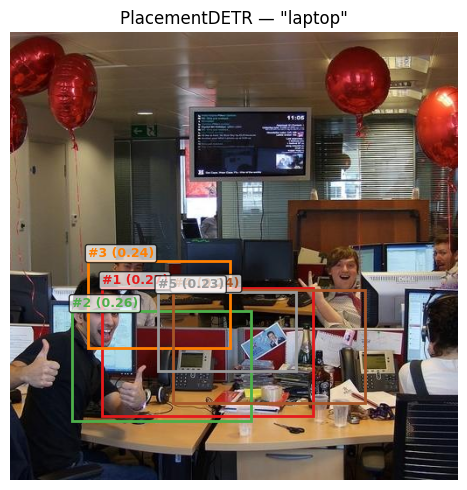

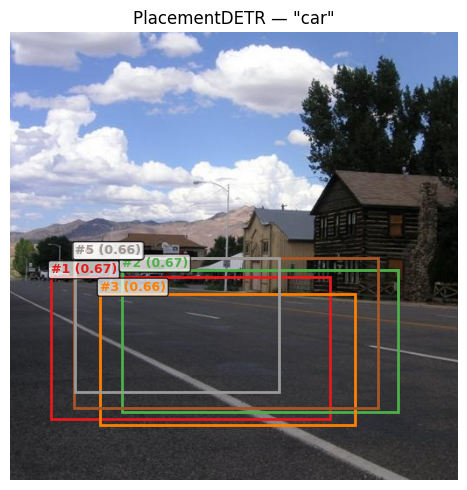

In [4]:
DEMO_EXAMPLES = [
    ("barn.jpg",        "horse"),
    ("bedroom.jpg",     "cat"),
    ("courtyard.jpg",   "bench"),
    ("desert_road.jpg", "motorcycle"),
    ("dining_room.jpg", "cake"),
    ("forest_path.jpg", "bicycle"),
    ("office.jpg",      "laptop"),
    ("residential.jpg", "car"),
]

for filename, class_name in DEMO_EXAMPLES:
    img_path = Path("demo_input") / filename
    img, preds = predict(img_path, class_name)
    show(img, preds, class_name)

## Try your own image

Replace the path and class name below to run on any background image.

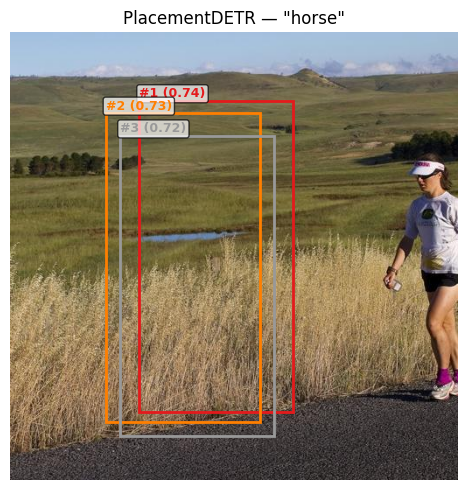

In [5]:
img, preds = predict("demo_input/barn.jpg", "horse", top_k=3)
show(img, preds, "horse")